In [1]:
import os
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

import matplotlib.pyplot as plt
import seaborn as sns

Download the dataset (TMDB_movie_dataset_v11.csv) and put it in the 'data' folder in the same directory as this file.

In [2]:
raw_data = pd.read_csv('data/TMDB_movie_dataset_v11.csv', header=0)

Start of preprocessing steps...

Our objective of data preprocessing:
1. Ensure genres, release_date, and popularity have no missing values.
2. Filter for status == 'Released' and popularity > 0.
3. If a movie has any Escapist tag (Sci-Fi, Fantasy, Animation, Horror, Family, Music), it is Escapist.
4. Remove metadata like backdrop_path, overview, and keywords.
5. Cap years at 2023 to avoid incomplete 2024-2025 data.
-- ?? --
6. Should we cap data to past 20 years from 2023? Unsure...

In [3]:
data = raw_data
print(f"Original data has {len(data)} records.")

data = data[data['status'] == 'Released']

# Delete these unwanted columns
to_ignore = ['id','title','status','backdrop_path', 'poster_path', 'homepage', 'imdb_id', 'tagline', 'overview','production_companies','keywords','original_title']
data = data.drop(columns=to_ignore)

data = data.dropna(subset=['release_date', 'popularity', 'genres'])
data = data[data['popularity'] > 0]

data['release_date'] = pd.to_datetime(data['release_date'])
data['year'] = data['release_date'].dt.year
data = data[(data['year'] >= 1900) & (data['year'] <= 2023)]

Original data has 1395267 records.


We need to set some initial assumptions in order to set ourselves for success. After careful analysis of dataset and its values, we chose to classify the following genres as "Escapist" and "Realists".

In [4]:
escapist = ['Science Fiction', 'Fantasy', 'Animation', 'Horror', 'Family','Music']
realist = ['Drama', 'History', 'Documentary', 'War', 'Crime', 'Mystery', 'Western','Romance']

We decided to use the strategy of "Dominant trait contamination". If the movie contains any genre that is subset of escapist, that essentially changes the entire voice and tone of the movie to be escapist. Hence we set that movie as escapist.

In [5]:
def assign_dominant_class(genre_str, e_tags, r_tags):
    movie_genres = {g.strip() for g in str(genre_str).split(',')}
    
    if movie_genres.intersection(e_tags):
        return 'Escapist'
    
    if movie_genres.intersection(r_tags):
        return 'Realist'
        
    return 'Other'



data['dominant_class'] = data['genres'].apply(lambda x: assign_dominant_class(x, set(escapist), set(realist)))

data['is_escapist'] = data['dominant_class'] == 'Escapist'
data['is_realist'] = data['dominant_class'] == 'Realist'

data = data[data['dominant_class'] != 'Other']

data = data[(data['runtime'] >= 45)&(data['runtime'] <= 300)]

In [6]:
print(f"Processed data has {len(data)} records.")
print(f"Processed data has {data['is_realist'].sum()} realist movies.")
print(f"Processed data has {data['is_escapist'].sum()} escapist movies.")
data.head(5)

Processed data has 300055 records.
Processed data has 216142 realist movies.
Processed data has 83913 escapist movies.


,vote_average,vote_count,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_countries,spoken_languages,year,dominant_class,is_escapist,is_realist
0,8.364,34495,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","United Kingdom, United States of America","English, French, Japanese, Swahili",2010,Escapist,True,False
1,8.417,32571,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","United Kingdom, United States of America",English,2014,Escapist,True,False
2,8.512,30619,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","English, Mandarin",2008,Realist,False,True
3,7.573,29815,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","English, Spanish",2009,Escapist,True,False
4,7.710,29166,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",United States of America,"English, Hindi, Russian",2012,Escapist,True,False


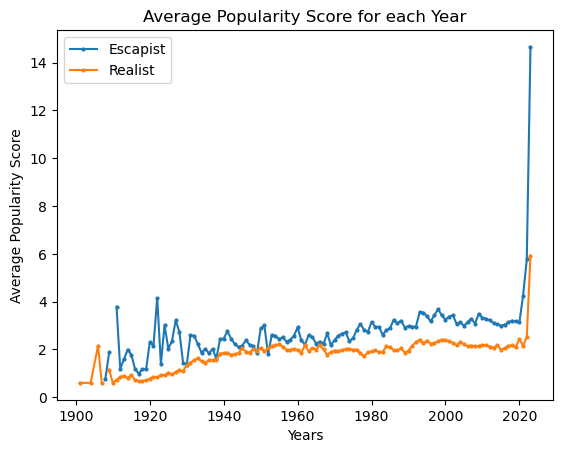

In [7]:
years = data['year'].to_numpy()
years = np.unique(years)
avg_popularity_e = []
avg_popularity_r = []

for year in years:
    avg_popularity_e += [data[(data['year']==year)&(data['is_escapist'])]['popularity'].mean()]
    avg_popularity_r += [data[(data['year']==year)&(data['is_realist'])]['popularity'].mean()]

plt.plot(years, avg_popularity_e, label='Escapist', marker='o', ms=2)
plt.plot(years, avg_popularity_r, label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Average Popularity Score')
plt.title('Average Popularity Score for each Year')
plt.legend()
plt.show()

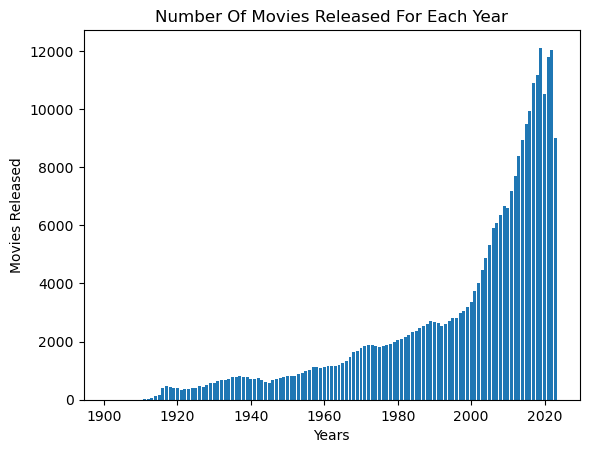

In [8]:
movies_per_year = []
for year in years:
    movies_per_year += [data[(data['year']==year)]['year'].count()]
#print(movies_per_year)

plt.bar(years, movies_per_year)
plt.xlabel('Years')
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released For Each Year')
plt.show()

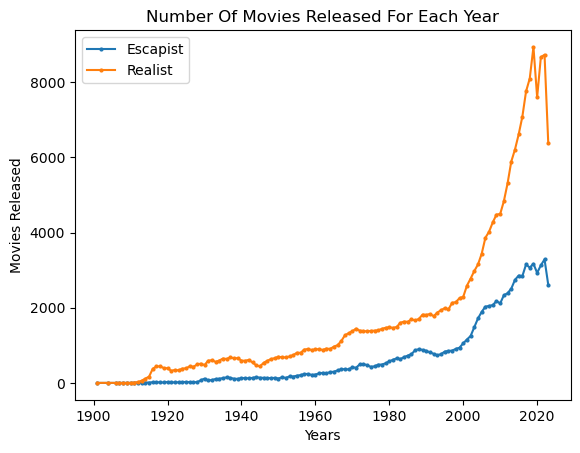

In [11]:
escapist_per_year = []
realist_per_year = []

for year in years:
    escapist_per_year += [data[(data['year']==year)&(data['is_escapist'])]['year'].count()]
    realist_per_year += [data[(data['year']==year)&(data['is_realist'])]['year'].count()]
#print(movies_per_year)

plt.plot(years, escapist_per_year, label='Escapist', marker='o', ms=2)
plt.plot(years, realist_per_year, label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released For Each Year')
plt.legend()
plt.show()

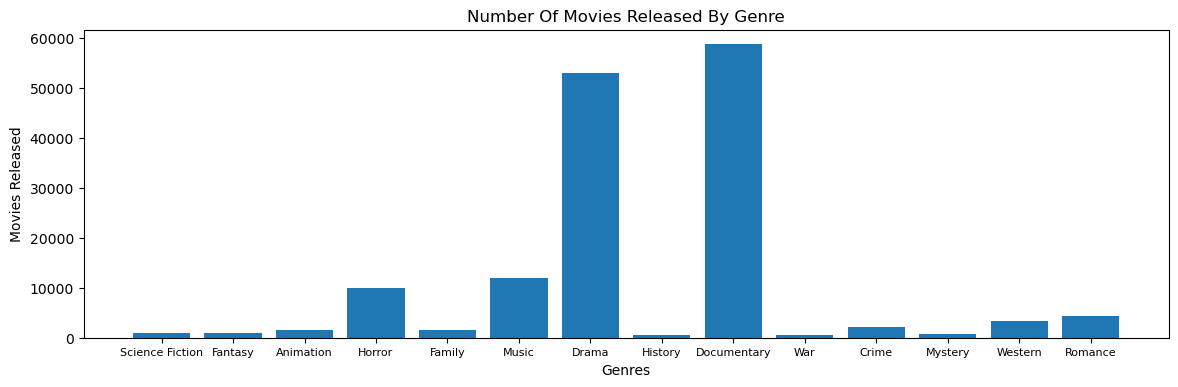

In [9]:
genres = escapist + realist
genre_counts = []

for g in genres:
    genre_counts += [data[(data['genres']==g)]['genres'].count()]

plt.figure(figsize=(14,4))
plt.bar(genres, genre_counts)
plt.xlabel('Genres')
plt.xticks(fontsize=8)
plt.ylabel('Movies Released')
plt.title('Number Of Movies Released By Genre')
plt.show()

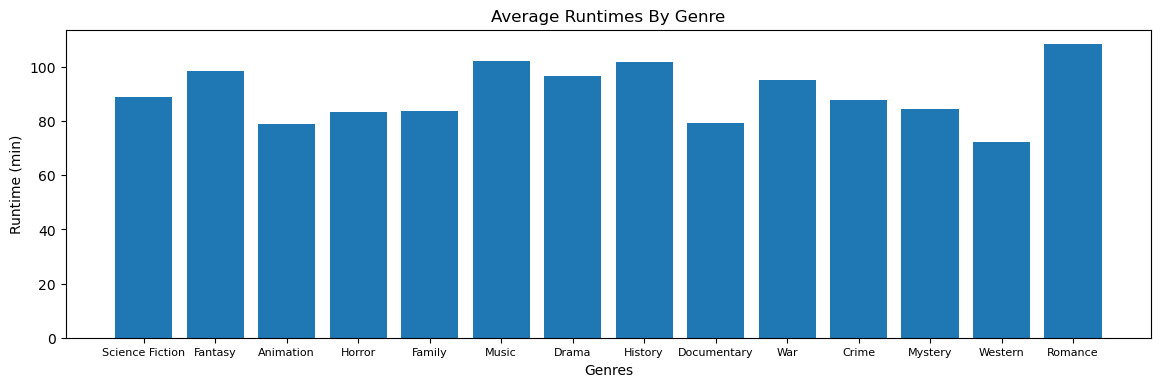

In [10]:
genre_avg_runtimes = []

for g in genres:
    genre_avg_runtimes += [data[(data['genres']==g)]['runtime'].mean()]

plt.figure(figsize=(14,4))
plt.bar(genres, genre_avg_runtimes)
plt.xlabel('Genres')
plt.xticks(fontsize=8)
plt.ylabel('Runtime (min)')
plt.title('Average Runtimes By Genre')
plt.show()

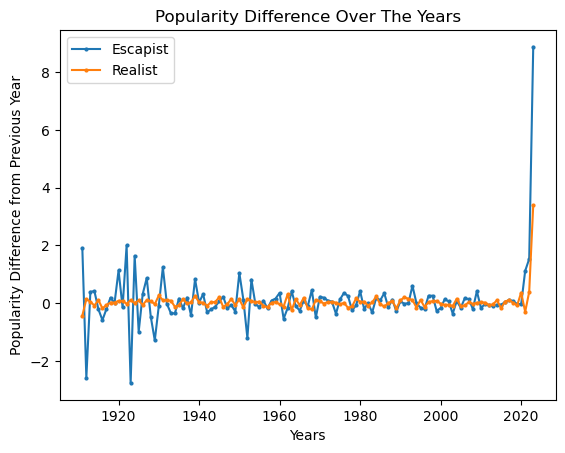

In [18]:
popularity_data = pd.DataFrame({'year':years, 'escapist_pop':avg_popularity_e, 'realist_pop':avg_popularity_r})
popularity_data = popularity_data.dropna()
popularity_data['escapist_diff'] = popularity_data['escapist_pop'].diff()
popularity_data['realist_diff'] = popularity_data['realist_pop'].diff()
popularity_data = popularity_data.dropna()

popularity_data.head(5)

plt.plot(popularity_data['year'], popularity_data['escapist_diff'], label='Escapist', marker='o', ms=2)
plt.plot(popularity_data['year'], popularity_data['realist_diff'], label='Realist', marker='o', ms=2)
plt.xlabel('Years')
plt.ylabel('Popularity Difference from Previous Year')
plt.title('Popularity Difference Over The Years')
plt.legend()
plt.show()

In [19]:
escapist_pos = popularity_data[popularity_data['escapist_diff'] > 0]['escapist_diff'].count()
realist_pos = popularity_data[popularity_data['realist_diff'] > 0]['realist_diff'].count()
print(f"Number of years the popularity increased for escapist movies: {escapist_pos}")
print(f"Number of years the popularity increased for realist movies: {realist_pos}")

Number of years the popularity increased for escapist movies: 55
Number of years the popularity increased for realist movies: 67
